# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.


### ✅ **Who (target audience)**

**Data scientists and business analysts working on (or evaluating) a credit card fraud detection model.**

They are responsible for:

* understanding fraud behavior
* deciding what features and models to invest in

---

### ✅ **What (single core message – the takeaway)**

Even though fraud transactions represent only **0.172% of all transactions**,
**their transaction amounts follow a clearly different distribution compared to legitimate transactions**,
which indicates that **transaction amount is a highly informative feature for fraud detection models.**

---

### ✅ **How (communication)**

I will use a **side-by-side violin plot with an overlaid box plot** for fraud vs. legitimate transactions to:

* show the **full distribution shape** (violin plot),
* highlight **median and spread** (box plot),
* and make the **difference in amount patterns immediately visible** between the two classes.

To support the message clearly, I will also:

* use a **log-scaled y-axis** for transaction amount (to handle extreme values),
* apply **consistent colors** for fraud vs. non-fraud,
* and add a short **annotation stating that fraud is only 0.172% of the data** to reinforce the business context.



# 3. Homework - work with your own data

In [73]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [74]:
# read the data
df = pd.read_csv("data/creditcard.csv")

# About the data
# The dataset contains transactions made by credit cards in September 2013 by European cardholders.
# This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. 
# The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.
# It contains only numerical input variables which are the result of a PCA transformation. 
# Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. 


In [75]:
# Sumarize the data
# using info() and describe()
df.info()            

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [76]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [77]:
# Finding duplicate rows
duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=list(df.columns)) # keep=False shows all duplicates including first occurrence
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique rows: {len(df) - df.duplicated().sum()}")

duplicate_rows

Total rows: 284807
Duplicate rows: 1081
Unique rows: 283726


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284192,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0
284193,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0
284190,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [78]:
# Get clean copy of the data
df_clean = df.drop_duplicates()

# Check for duplicate rows
print(f"Original rows: {len(df)}")
print(f"After removing duplicates: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} duplicate rows")

Original rows: 284807
After removing duplicates: 283726
Removed: 1081 duplicate rows


In [79]:
# lets check for missing values
print("Missing values in df_clean:")
print(df_clean.isnull().sum())


Missing values in df_clean:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [80]:
# Percentage of missing values
print("Percentage of missing values in df_clean:")
print(df_clean.isnull().sum() / len(df_clean) * 100)

Percentage of missing values in df_clean:
Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64


In [ ]:
# Data type checks
print("Data type checks:")
print(df_clean.dtypes)
# Check for mixed data types
print("Mixed data types in df_clean:")
print(df_clean.apply(lambda x: x.map(type).nunique()))


Data type checks:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Mixed data types in df_clean:
Time      1
V1        1
V2        1
V3        1
V4        1
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: i

Class imbalance:
Class
0    283253
1       473
Name: count, dtype: int64


<Axes: xlabel='Class'>

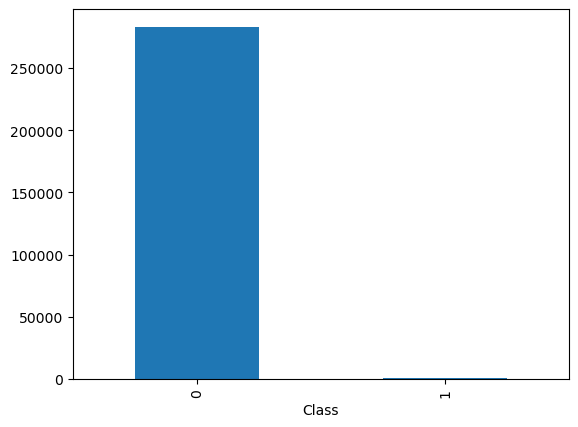

In [82]:
# 3. Class Imbalance (Fraud vs Non-Fraud)
print("Class imbalance:")
print(df_clean['Class'].value_counts())
# Percentage distribution
df_clean['Class'].value_counts(normalize=True) * 100

# Visualization
df_clean['Class'].value_counts().plot(kind='bar')

In [83]:
# 4. Basic Statistics
print("Basic statistics:")
df_clean['Amount'].describe()
df_clean['Time'].describe()


Basic statistics:


count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

In [84]:
# 5. Outliers
print("Outliers:")
df_clean['Amount'].quantile([0.01,0.25,0.5,0.75,0.95,0.99])


Outliers:


0.01       0.1200
0.25       5.6000
0.50      22.0000
0.75      77.5100
0.95     365.3375
0.99    1018.9650
Name: Amount, dtype: float64

<Axes: >

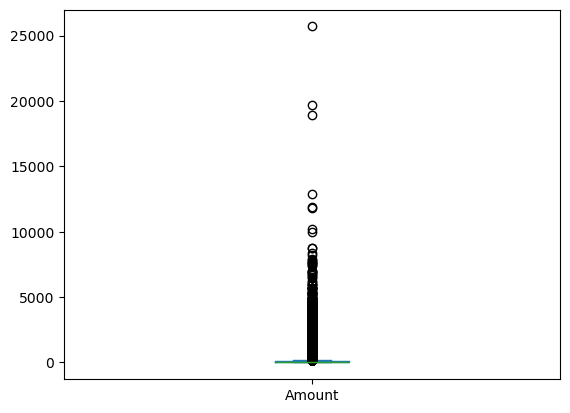

In [85]:
# Boxplot
df_clean['Amount'].plot(kind='box')

In [86]:
# Check the stream values
df_clean[df_clean['Amount'] > df_clean['Amount'].quantile(0.99)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
51,36.0,-1.004929,-0.985978,-0.038039,3.710061,-6.631951,5.122103,4.371691,-2.006868,-0.278736,...,1.393406,-0.381671,0.969719,0.019445,0.570923,0.333278,0.857373,-0.075538,1402.95,0
89,59.0,-0.773293,-4.146007,-0.932038,0.027094,-1.698307,0.460188,0.737344,-0.314216,-0.842673,...,0.890978,0.026123,-1.134769,-0.654958,0.098386,-0.209150,-0.171709,0.208057,1142.02,0
164,103.0,-6.093248,-12.114213,-5.694973,3.294389,-1.413792,4.776000,4.808426,-0.228197,-0.525896,...,2.228823,-2.264037,-3.553381,1.215279,-0.406073,-0.653384,-0.711222,0.672900,3828.04,0
865,656.0,-1.789835,-5.835768,-1.472791,-0.851160,-2.433875,0.401415,1.354543,-0.288283,2.426889,...,1.081404,-0.178233,-1.635914,-0.645651,0.112930,-0.726724,-0.184806,0.296762,1602.99,0
1027,775.0,-3.900810,-3.098370,-0.213428,-2.678434,-2.927576,0.735688,1.591471,-3.465433,1.812757,...,-1.357870,-0.097578,-4.020300,0.191246,-0.204492,-1.076721,1.072961,-0.188497,1528.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283875,171943.0,0.087032,-2.727628,-3.215031,2.216197,-0.229633,-1.419572,2.553476,-0.987507,-0.614069,...,0.969833,0.738640,-1.082522,0.535977,0.474597,-0.330842,-0.235690,0.105630,1026.46,0
284154,172199.0,-1.448606,-2.673922,-3.563343,-0.194096,0.007561,4.999178,4.136303,0.159725,-2.951736,...,0.644819,0.520282,2.202927,0.683422,0.446953,1.403290,-0.242420,0.221515,1088.04,0
284249,172273.0,-9.030538,-11.112584,-16.233798,3.592021,-40.427726,23.917837,44.054461,-7.277778,-4.210637,...,-0.269048,0.988144,7.040028,0.347693,2.520869,2.342495,3.478175,-2.713136,10199.44,0
284383,172397.0,-0.065120,-4.114668,-2.106854,-0.137339,-1.384530,0.239999,0.893833,-0.257922,1.145888,...,0.395868,-1.244969,-0.686403,-0.963878,-0.924685,0.210599,-0.253408,0.125687,1114.00,0


In [87]:
# 6. Value Ranges
# Check min/max for all columns
print("Min values:")
print(df_clean.min())
print("\nMax values:")
print(df_clean.max())

# Check for negative values where they shouldn't be
(df_clean['Amount'] < 0).sum()

Min values:
Time        0.000000
V1        -56.407510
V2        -72.715728
V3        -48.325589
V4         -5.683171
V5       -113.743307
V6        -26.160506
V7        -43.557242
V8        -73.216718
V9        -13.434066
V10       -24.588262
V11        -4.797473
V12       -18.683715
V13        -5.791881
V14       -19.214325
V15        -4.498945
V16       -14.129855
V17       -25.162799
V18        -9.498746
V19        -7.213527
V20       -54.497720
V21       -34.830382
V22       -10.933144
V23       -44.807735
V24        -2.836627
V25       -10.295397
V26        -2.604551
V27       -22.565679
V28       -15.430084
Amount      0.000000
Class       0.000000
dtype: float64

Max values:
Time      172792.000000
V1             2.454930
V2            22.057729
V3             9.382558
V4            16.875344
V5            34.801666
V6            73.301626
V7           120.589494
V8            20.007208
V9            15.594995
V10           23.745136
V11           12.018913
V12            7.8483

0

In [88]:
# 7. Data Shape and Size
# Total records
print(f"Total transactions: {len(df_clean)}")
print(f"Total features: {df_clean.shape[1]}")

# Memory usage
df_clean.memory_usage(deep=True).sum() / 1024**2  # in MB

Total transactions: 283726
Total features: 31


69.26904296875

In [89]:
# 8. Time column Analysis
# Check time range (Time is in seconds from first transaction)
print(df_clean['Time'].min(), df_clean['Time'].max())

# Convert to hours for readability
print(df_clean['Time'].max() / 3600)  # hours

# Check if time is sequential
print(df_clean['Time'].is_monotonic_increasing)

0.0 172792.0
47.99777777777778
True


In [90]:
# 9. Zero values
# Check for zero values in Amount (valid transactions?)
(df_clean['Amount'] == 0).sum()

# Zero values across all columns
(df_clean == 0).sum()

Time           2
V1             0
V2             0
V3             0
V4             0
V5             0
V6             0
V7             0
V8             0
V9             0
V10            0
V11            0
V12            0
V13            0
V14            0
V15            0
V16            0
V17            0
V18            0
V19            0
V20            0
V21            0
V22            0
V23            0
V24            0
V25            0
V26            0
V27            0
V28            0
Amount      1808
Class     283253
dtype: int64

In [91]:
# 10. Correlation Analysis
# Check correlation between features
correlation = df_clean.corr()

# High correlations (multicollinearity)
import numpy as np
high_corr = np.where(np.abs(correlation) > 0.9)
high_corr_list = [(correlation.index[x], correlation.columns[y]) 
                  for x, y in zip(*high_corr) if x != y and x < y]

In [92]:
# 11. Fraud Analysis
# Separate fraud and legitimate transactions
fraud = df_clean[df_clean['Class'] == 1]
legitimate = df_clean[df_clean['Class'] == 0]

print(f"Fraud transactions: {len(fraud)}")
print(f"Legitimate transactions: {len(legitimate)}")

# Compare statistics
fraud['Amount'].describe()
legitimate['Amount'].describe()

Fraud transactions: 473
Legitimate transactions: 283253


count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

In [93]:
# 12. Data Consistency
# Check if Class only has 0 and 1
df_clean['Class'].unique()

# Check for unexpected values in any column
for col in df_clean.columns:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")



Time: 124592 unique values

V1: 275663 unique values

V2: 275663 unique values

V3: 275663 unique values

V4: 275663 unique values

V5: 275663 unique values

V6: 275663 unique values

V7: 275663 unique values

V8: 275663 unique values

V9: 275663 unique values

V10: 275663 unique values

V11: 275663 unique values

V12: 275663 unique values

V13: 275663 unique values

V14: 275663 unique values

V15: 275663 unique values

V16: 275663 unique values

V17: 275663 unique values

V18: 275663 unique values

V19: 275663 unique values

V20: 275663 unique values

V21: 275663 unique values

V22: 275663 unique values

V23: 275663 unique values

V24: 275663 unique values

V25: 275663 unique values

V26: 275663 unique values

V27: 275663 unique values

V28: 275663 unique values

Amount: 32767 unique values

Class: 2 unique values


In [94]:
# 13. Quick comprehensive check function
def quick_data_check(df_clean):
    print("="*50)
    print("DATA QUALITY REPORT")
    print("="*50)
    print(f"\n1. Shape: {df_clean.shape}")
    print(f"\n2. Missing Values:\n{df_clean.isnull().sum()}")
    print(f"\n3. Duplicates: {df_clean.duplicated().sum()}")
    print(f"\n4. Data Types:\n{df_clean.dtypes}")
    print(f"\n5. Class Distribution:\n{df_clean['Class'].value_counts()}")
    print(f"\n6. Memory Usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("="*50)

quick_data_check(df_clean)

DATA QUALITY REPORT

1. Shape: (283726, 31)

2. Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

3. Duplicates: 0

4. Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       flo

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

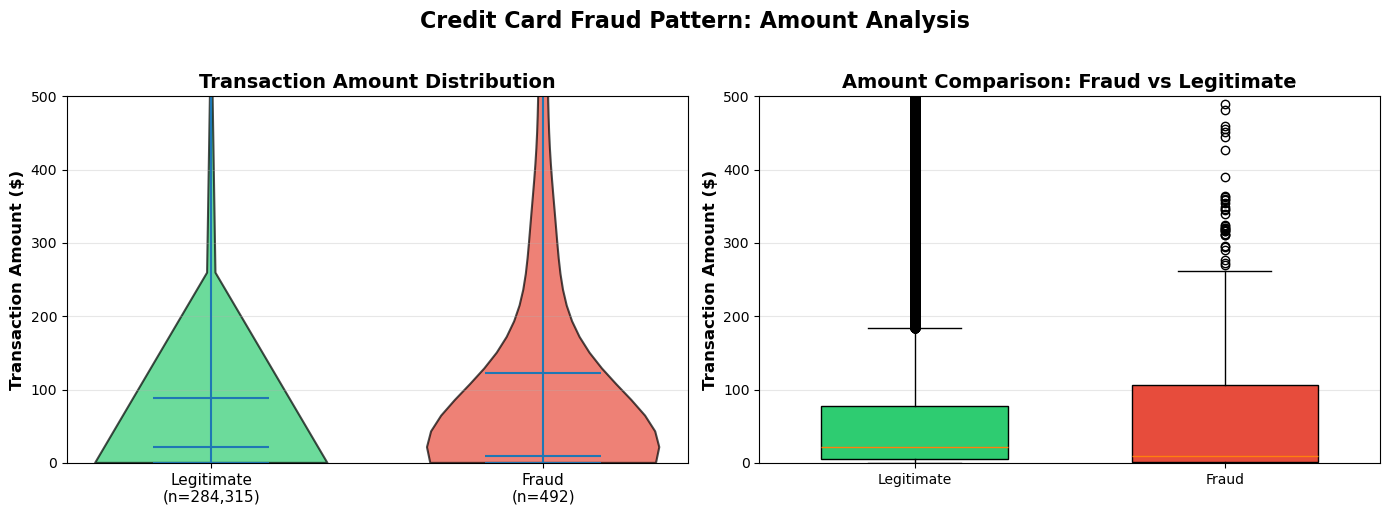

In [95]:
# Graph with original data to show Fraud transactions have distinctly higher amount than legitimate transactions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seperate fraud and legitimate transactions
fraud = df[df['Class'] == 1]
legitimate = df[df['Class'] == 0]

# Left Plot:  Violin plot
parts = axes[0].violinplot([legitimate['Amount'], fraud['Amount']], 
                           positions=[1, 2],
                           showmeans=True,
                           showmedians=True,
                           widths=0.7)
# Color the violins
parts['bodies'][0].set_facecolor('#2ecc71')
parts['bodies'][0].set_alpha(0.7)
parts['bodies'][0].set_edgecolor('black')
parts['bodies'][0].set_linewidth(1.5)
parts['bodies'][1].set_facecolor('#e74c3c')
parts['bodies'][1].set_alpha(0.7)
parts['bodies'][1].set_edgecolor('black')
parts['bodies'][1].set_linewidth(1.5)

axes[0].set_xticks([1, 2])
axes[0].set_xticklabels([f'Legitimate\n(n={len(legitimate):,})', 
                     f'Fraud\n(n={len(fraud):,})'], fontsize=11)
axes[0].set_ylabel('Transaction Amount ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 500) # Set y-axis limits to focus on main range
axes[0].grid(axis='y', alpha=0.3)

# Right Plot: Boxplot comparison
data_to_plot = [legitimate['Amount'], fraud['Amount']]
bp = axes[1].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'], patch_artist=True, widths=0.6)

# Color the boxes
bp['boxes'][0].set(facecolor='#2ecc71')
bp['boxes'][1].set(facecolor='#e74c3c')
axes[1].set_ylabel('Transaction Amount ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Amount Comparison: Fraud vs Legitimate', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 500) # Set y-axis limits to focus on main range
axes[1].grid(axis='y', alpha=0.3)

# Add overall title
fig.suptitle('Credit Card Fraud Pattern: Amount Analysis', fontsize=16, fontweight='bold', y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()




In [96]:
# Check the imbalance
print(f"Legitimate: {len(df_clean[df_clean['Class']==0])}")
print(f"Fraud: {len(df_clean[df_clean['Class']==1])}")
print(f"Ratio: {len(df_clean[df_clean['Class']==0]) / len(df_clean[df_clean['Class']==1]):.0f}:1")

Legitimate: 283253
Fraud: 473
Ratio: 599:1
